# MCTS Drug Design Testing Notebook

Testing the Monte Carlo Tree Search (MCTS) module for de novo drug design using R-BRICS fragments.
This notebook demonstrates how to:
- Load fragment libraries
- Configure the MCTS engine with custom scoring functions
- Generate molecular candidates
- Analyze and visualize the results

## 1. Import Required Libraries

Import necessary libraries including pandas, NumPy, RDKit, and the MCTSDrugDesign class with make_composite_scorer.

In [33]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from pathlib import Path
import pyarrow as pa

from rdkit import Chem
from rdkit.Chem import Draw

from smiles_blocks.mcts import MCTSDrugDesign
from smiles_blocks.rbrics_patterns import RBRICSCompatibilityMap
from smiles_blocks.files import INTERIM_DATA_DIR

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Fragment Library and Compatibility Map

Load the fragment DataFrame from a CSV or pickle file and retrieve the R-BRICS compatibility map for fragment connection rules.

In [16]:
# Define paths
block_library_dir = INTERIM_DATA_DIR / "well_sampled" / "block_library"
df_list = [pd.read_parquet(file) for file in block_library_dir.glob("*.parquet")]
df  = pd.concat(df_list, ignore_index=True)

In [17]:
df_unique =df.drop_duplicates(subset="unique_id")

logger.info(f"Loaded {len(df_unique)} unique fragments")
print(f"Unique Fragment DataFrame shape: {df_unique.shape}")
print(f"Columns: {list(df_unique.columns)}")


# Get compatibility map from R-BRICS patterns
compat = dict(RBRICSCompatibilityMap().patterns)
logger.info(f"Loaded R-BRICS compatibility map with {len(compat)} connection rules")
print(f"\nCompatibility map keys: {list(compat.keys())}")

INFO:__main__:Loaded 119645 unique fragments
INFO:__main__:Loaded R-BRICS compatibility map with 25 connection rules


Unique Fragment DataFrame shape: (119645, 14)
Columns: ['block', 'can_smiles', 'first_connected_can_idx', 'last_connected_can_idx', 'unique_id', 'begin_tag', 'end_tag', 'MolWt', 'nHDonors', 'nHAcceptors', 'nRotatableBonds', 'CrippenlogP', 'TPSA', 'status']

Compatibility map keys: ['L1', 'L30', 'L3', 'L4', 'L5', 'L51', 'L6', 'L7a', 'L8', 'L81', 'L9', 'L10', 'L11', 'L12b', 'L13', 'L14', 'L14b', 'L15', 'L16', 'L16b', 'L17', 'L18', 'L182', 'L20', 'L22']


In [5]:
blocked_smiles_dir = INTERIM_DATA_DIR / "well_sampled" / "blocked_smiles"
df_list = [pd.read_parquet(file) for file in blocked_smiles_dir.glob("*.parquet")]
df_blocked_smiles = pd.concat(df_list, ignore_index=True)

In [26]:
successful_blocking = df_blocked_smiles[df_blocked_smiles["fragmentation_success"]]

In [27]:
def count_block_counts(blocked_smiles: str) -> Counter:
    """Count the frequency of each block in a blocked SMILES string."""
    list_of_blocks = blocked_smiles.split(".")
    return Counter(list_of_blocks)

# Notebook-safe implementation: avoid multiprocessing pool workers trying to
# import a function from __main__.
block_counts_list = [
    count_block_counts(smiles)
    for smiles in successful_blocking["smiles_blocked"].tolist()
]

aggregated_counts = Counter()
for block_count in block_counts_list:
    aggregated_counts.update(block_count)

aggregated_counts

Counter({'N': 1388233,
         'C(=O)': 1060058,
         'C': 673089,
         'O': 388391,
         'C-C': 373183,
         'O-C': 243737,
         'C-C(=O)': 204602,
         'C(=O)-C': 203301,
         'S(=O)(=O)': 141333,
         'N(-C)': 136655,
         'C1-C=C-C(=C-C=1)': 117497,
         'C1=C-C=C(-C=C-1)': 116875,
         'C(-C)': 113348,
         'S': 109006,
         'C1=C-C=C-C=C-1': 98950,
         'C(-C)-C': 97461,
         'C-O': 79731,
         'C#N': 72069,
         'C-C-C': 71624,
         'N1-C-C-N(-C-C-1)': 70965,
         'O(-C)': 64463,
         'C1-C-C-1': 64304,
         'C1-C(=C-C=C-C=1)': 58746,
         'C1-C=C-C=C-C=1': 50850,
         'C1-C=C-C=C(-C=1)': 48455,
         'C1=C-C(=C-C=C-1)': 48170,
         'C-C-C(=O)': 46855,
         'C(=O)-C-C': 42260,
         'C1=C-C=C-C(=C-1)': 38919,
         'C1-C=C(-C=C-C=1)': 38578,
         'C(-C)(-C)': 36449,
         'C-C(-C)': 31514,
         'N(-C-C)': 31290,
         'C(-C)-C(=O)': 30965,
         'C(-C)(-

In [28]:
block2unique_id = {block: unique_id for unique_id, block in zip(df["unique_id"], df["block"])}

In [29]:
unique_id_counts = {unique_id : 0 for unique_id in df["unique_id"]}
not_found_count = 0

for block, count in aggregated_counts.items():
    unique_id = block2unique_id.get(block)
    if unique_id is not None:
        unique_id_counts[unique_id] += count
    else:
        not_found_count += 1
        logger.warning(f"Block '{block}' not found in block2unique_id mapping")

In [30]:
not_found_count

0

In [32]:
df_unique["frequency"] = df_unique["unique_id"].map(unique_id_counts)

## 3. Initialize MCTS Drug Designer

Create an MCTSDrugDesign instance with the fragment library, compatibility map, and custom scoring function using make_composite_scorer with specified weights and thresholds.

In [34]:
fragment_table = pa.Table.from_pandas(df_unique)

In [ ]:
# Initialize MCTS Drug Designer
mcts = MCTSDrugDesign(
    fragment_table=fragment_table,
    compatibility_map=compat,
    block_count_mu=5.5,
    block_count_sigma=1.41,
    n_iter=10_000,
    min_blocks=3,
    max_blocks=10,
)

logger.info("MCTS Drug Designer initialized")

INFO:__main__:MCTS Drug Designer initialized


## 4. Run MCTS to Generate Molecules

Execute the MCTS search with n_molecules=100 to generate candidate drug molecules and collect results including SMILES, scores, block counts, and fragment IDs.

In [ ]:
print("Running MCTS search to generate 100 molecules...")
print("This may take a few minutes...\n")

results = mcts.run(n_runs=100)

print(f"\nGenerated {len(results)} molecules")
print(f"Results keys: {results[0].keys() if results else 'N/A'}")

Running MCTS search to generate 100 molecules...
This may take a few minutes...



INFO:smiles_blocks.mcts:Generated 1000 / 1000 molecules.



Generated 1000 molecules
Results keys: dict_keys(['smiles', 'score', 'n_blocks', 'fragment_ids'])


## 5. Analyze Results

Convert results to a pandas DataFrame and compute summary statistics including score distribution, block count distribution, and identify top-scoring candidates.

In [38]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Summary statistics
print("=== RESULTS SUMMARY ===\n")
print(f"Total molecules generated: {len(results_df)}")
print(f"\nScore Statistics:")
print(results_df['score'].describe())
print(f"\nBlock Count Statistics:")
print(results_df['n_blocks'].describe())

# Top scoring molecules
top_n = 10
print(f"\n=== TOP {top_n} MOLECULES ===")
top_df = results_df.nlargest(top_n, 'score')[['smiles', 'score', 'n_blocks']]
print(top_df.to_string(index=False))

# Save results
output_file = Path("../data/processed") / "mcts_results.csv"
output_file.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_file, index=False)
logger.info(f"Results saved to {output_file}")
print(f"\nResults saved to: {output_file}")

INFO:__main__:Results saved to ../data/processed/mcts_results.csv


=== RESULTS SUMMARY ===

Total molecules generated: 1000

Score Statistics:
count    1000.000000
mean        0.994250
std         0.045072
min         0.500000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: score, dtype: float64

Block Count Statistics:
count    1000.000000
mean        4.224000
std         1.298272
min         2.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         9.000000
Name: n_blocks, dtype: float64

=== TOP 10 MOLECULES ===
                                                                           smiles  score  n_blocks
                                     C(-C-C)(-C)N-C1-C(=O)-N(-C)-C2-C-1=C-C=C-C=2    1.0         2
                                         C(-C)NC1-N2-C(=N-N=C-2)-N=C2-C-C-C-C=1-2    1.0         3
                       N-C(=O)C1=C-C=C2-C(-C)=C(-S-C-2=N-1)C1-N-C(=O)-C=C(-N)-N=1    1.0         3
         N1(-C)-C(=N-N=C-1-N)C1=C-C=C2-N(-C-C-C-C-2=C-1)C1-S-C2-C(-N=1)=C-C=C-C=2 

## 6. Visualize Results

Display molecular structures of top-scoring molecules using RDKit and create plots showing score vs. block count and other relevant metrics.

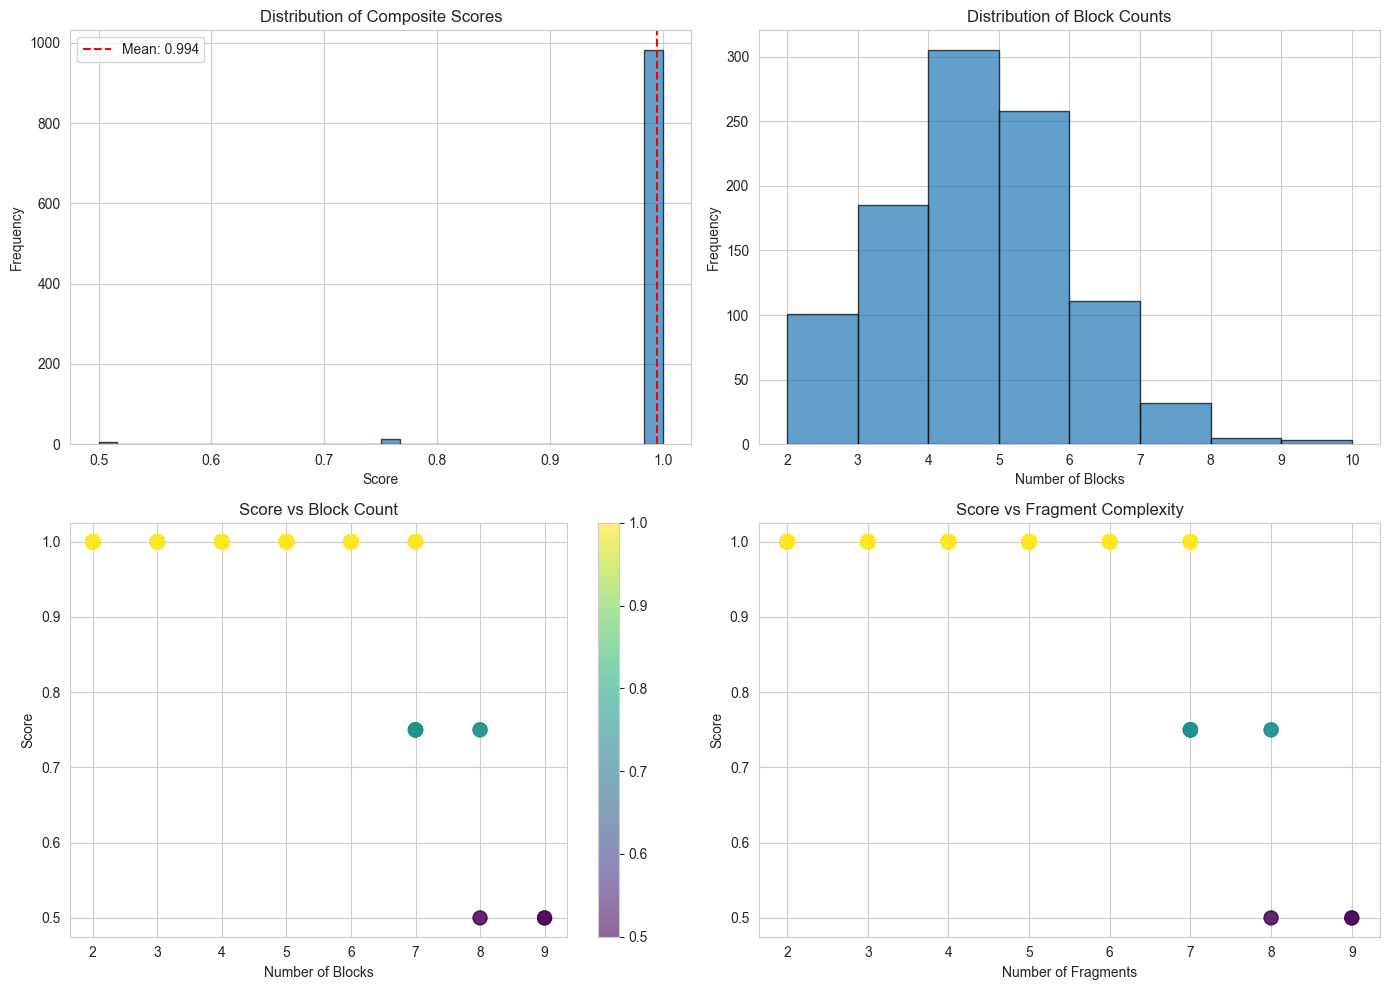

Visualization complete!


In [39]:
# Plot 1: Score distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Score histogram
axes[0, 0].hist(results_df['score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Composite Scores')
axes[0, 0].axvline(results_df['score'].mean(), color='red', linestyle='--', label=f"Mean: {results_df['score'].mean():.3f}")
axes[0, 0].legend()

# Block count distribution
axes[0, 1].hist(results_df['n_blocks'], bins=range(int(results_df['n_blocks'].min()), int(results_df['n_blocks'].max()) + 2), edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of Blocks')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Block Counts')

# Score vs block count scatter plot
scatter = axes[1, 0].scatter(results_df['n_blocks'], results_df['score'], alpha=0.6, c=results_df['score'], cmap='viridis', s=100)
axes[1, 0].set_xlabel('Number of Blocks')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Score vs Block Count')
plt.colorbar(scatter, ax=axes[1, 0])

# Score vs fragment count (proxy for complexity)
axes[1, 1].scatter(results_df['fragment_ids'].apply(len), results_df['score'], alpha=0.6, c=results_df['score'], cmap='viridis', s=100)
axes[1, 1].set_xlabel('Number of Fragments')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Score vs Fragment Complexity')

plt.tight_layout()
plt.show()

print("Visualization complete!")

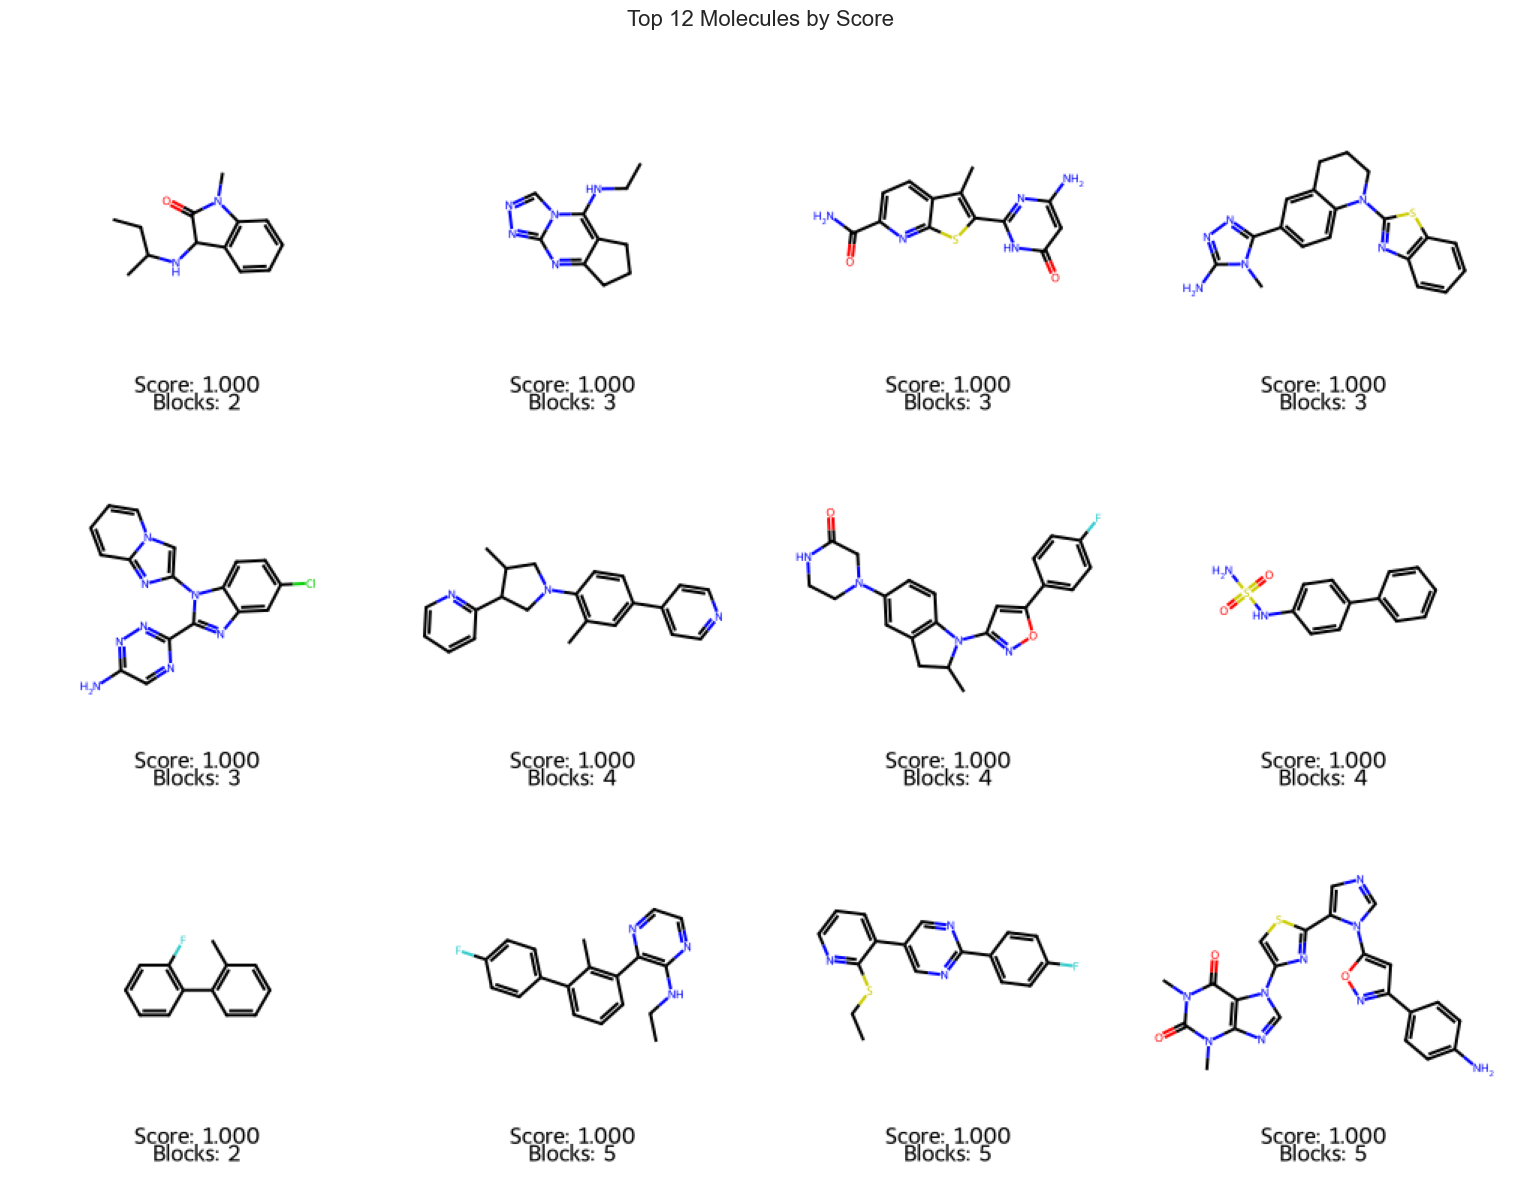

In [40]:
# Display top 12 molecule structures
top_mols = results_df.nlargest(12, 'score')
mols = []
legends = []

for idx, row in top_mols.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol is not None:
        mols.append(mol)
        legends.append(f"Score: {row['score']:.3f}\nBlocks: {row['n_blocks']}")

if mols:
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(250, 250),
        legends=legends,
        returnPNG=False
    )
    plt.figure(figsize=(16, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Top 12 Molecules by Score', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Could not generate molecule structures from SMILES strings")